# Olist E-Commerce Data Cleaning
## Transforming Raw Data into Analysis-Ready Format

**Goal:** Fix data quality issues identified in exploration and create a clean dataset.

**What we will do:**
1. Handle missing values
2. Fix data types
3. Remove/correct outliers
4. Standardize column names
5. Create a clean, analysis-ready dataset

---
## Step 1: Import Libraries and Load Data

In [85]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

# Define paths
DATA_PATH = r"C:\Users\KIIT\Desktop\projects\Brazilian E-Commerce Public Dataset by Olist\Data"
OUTPUT_PATH = r"C:\Users\KIIT\Desktop\projects\olist-analytics\data\processed"

# Ensure output directory exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Setup complete!")

Setup complete!


In [86]:
# Load the master dataset
df = pd.read_csv(os.path.join(DATA_PATH, 'master.csv'))

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 112,650 rows x 30 columns


---
## Step 2: Document Initial Data Quality Issues

In [87]:
# Create a data quality report
print("=" * 60)
print("INITIAL DATA QUALITY ASSESSMENT")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\n1. MISSING VALUES:")
if len(missing_df) > 0:
    for col, row in missing_df.iterrows():
        print(f"   - {col}: {row['Missing Count']:,} ({row['Missing %']:.1f}%)")
else:
    print("   No missing values!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n2. DUPLICATE ROWS: {duplicates:,}")

print("\n" + "=" * 60)

INITIAL DATA QUALITY ASSESSMENT

1. MISSING VALUES:
   - delay_days: 2,461.0 (2.2%)
   - actual_delivery_days: 2,461.0 (2.2%)
   - is_late: 2,453.0 (2.2%)
   - delay_bucket: 2,453.0 (2.2%)
   - review_score: 942.0 (0.8%)
   - sentiment: 942.0 (0.8%)
   - total_payment: 3.0 (0.0%)
   - payment_type: 3.0 (0.0%)
   - installments: 3.0 (0.0%)

2. DUPLICATE ROWS: 0



In [88]:
# Handle missing delivery-related columns
delivery_cols = ['delay_days', 'is_late', 'delay_bucket', 'actual_delivery_days']

for col in delivery_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            print(f"Column '{col}': {missing_count} missing (likely undelivered orders)")
            df['is_delivered'] = df[col].notna()

# Check order status for undelivered orders
if 'order_status' in df.columns:
    undelivered = df[df['order_status'] != 'delivered']
    print(f"\nUndelivered orders by status:")
    print(undelivered['order_status'].value_counts())

# IMPORTANT NOTE: customer_id vs customer_unique_id
# In the Olist master.csv:
# - 'customer_id' is actually a per-order reference (same customer can have different IDs across orders)
# - 'customer_unique_id' is the TRUE unique customer identifier
# We will handle this in feature_engineering notebook
print("\n⚠️  NOTE: 'customer_id' in this dataset is per-order, 'customer_unique_id' is the true customer ID")
print("   Will rename in feature engineering step for clarity")

Column 'delay_days': 2461 missing (likely undelivered orders)
Column 'is_late': 2453 missing (likely undelivered orders)
Column 'delay_bucket': 2453 missing (likely undelivered orders)
Column 'actual_delivery_days': 2461 missing (likely undelivered orders)

Undelivered orders by status:
order_status
shipped        1185
canceled        542
invoiced        359
processing      357
unavailable       7
approved          3
Name: count, dtype: int64

⚠️  NOTE: 'customer_id' in this dataset is per-order, 'customer_unique_id' is the true customer ID
   Will rename in feature engineering step for clarity


In [89]:
# Store original row count
original_rows = len(df)
print(f"Original row count: {original_rows:,}")

# Check for missing critical identifiers
critical_cols = ['order_id', 'customer_id', 'product_id', 'seller_id']
for col in critical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        print(f"Warning: {col} has {missing_count} missing values - dropping these rows")
        df = df.dropna(subset=[col])
    else:
        print(f"OK: {col} has no missing values")

print(f"\nRows after dropping missing IDs: {len(df):,}")

Original row count: 112,650
OK: order_id has no missing values
OK: customer_id has no missing values
OK: product_id has no missing values
OK: seller_id has no missing values

Rows after dropping missing IDs: 112,650


In [90]:
# Handle missing category values - Fill with 'Unknown'
if 'category' in df.columns:
    missing_category = df['category'].isnull().sum()
    if missing_category > 0:
        print(f"Filling {missing_category} missing category values with 'Unknown'")
        df['category'] = df['category'].fillna('Unknown')
    else:
        print("No missing category values")

No missing category values


In [91]:
# Handle missing review scores
if 'review_score' in df.columns:
    missing_reviews = df['review_score'].isnull().sum()
    if missing_reviews > 0:
        print(f"Creating 'has_review' flag for {missing_reviews} orders without reviews")
        df['has_review'] = ~df['review_score'].isnull()
        df['review_score'] = df['review_score'].fillna(0)
    else:
        df['has_review'] = True

Creating 'has_review' flag for 942 orders without reviews


In [92]:
# Handle missing delivery-related columns
delivery_cols = ['delay_days', 'is_late', 'delay_bucket', 'actual_delivery_days']

for col in delivery_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            print(f"Column '{col}': {missing_count} missing (likely undelivered orders)")
            df['is_delivered'] = df[col].notna()

# Check order status for undelivered orders
if 'order_status' in df.columns:
    undelivered = df[df['order_status'] != 'delivered']
    print(f"\nUndelivered orders by status:")
    print(undelivered['order_status'].value_counts())

Column 'delay_days': 2461 missing (likely undelivered orders)
Column 'is_late': 2453 missing (likely undelivered orders)
Column 'delay_bucket': 2453 missing (likely undelivered orders)
Column 'actual_delivery_days': 2461 missing (likely undelivered orders)

Undelivered orders by status:
order_status
shipped        1185
canceled        542
invoiced        359
processing      357
unavailable       7
approved          3
Name: count, dtype: int64


---
## Step 4: Fix Data Types

In [93]:
# Convert date columns to datetime
date_cols = ['order_purchase_timestamp', 'shipping_limit_date']

print("Converting date columns:")
for col in date_cols:
    if col in df.columns:
        print(f"  - {col}: converting to datetime")
        df[col] = pd.to_datetime(df[col])

print("\nDate column types after conversion:")
for col in date_cols:
    if col in df.columns:
        print(f"  {col}: {df[col].dtype}")

Converting date columns:
  - order_purchase_timestamp: converting to datetime
  - shipping_limit_date: converting to datetime

Date column types after conversion:
  order_purchase_timestamp: datetime64[ns]
  shipping_limit_date: datetime64[ns]


In [94]:
# Handle missing payment values BEFORE converting to category
if 'payment_type' in df.columns:
    missing_payment = df['payment_type'].isnull().sum()
    if missing_payment > 0:
        print(f"Filling {missing_payment} missing payment_type values with 'unknown'")
        df['payment_type'] = df['payment_type'].fillna('unknown')
        # Also fill related columns
        if 'payment_total' in df.columns:
            df['payment_total'] = df['payment_total'].fillna(0)
        if 'installments' in df.columns:
            df['installments'] = df['installments'].fillna(0)

# Convert boolean-like columns to actual boolean
if 'is_late' in df.columns:
    print("Converting 'is_late' to boolean...")
    df['is_late'] = df['is_late'].astype('boolean')
    print(f"  is_late dtype: {df['is_late'].dtype}")

Filling 3 missing payment_type values with 'unknown'
Converting 'is_late' to boolean...
  is_late dtype: boolean


In [95]:
# Convert categorical columns to category dtype (saves memory)
cat_cols = ['order_status', 'payment_type', 'sentiment', 'category', 
            'customer_state', 'seller_state', 'delay_bucket']

print("Converting categorical columns:")
for col in cat_cols:
    if col in df.columns:
        unique_vals = df[col].nunique()
        print(f"  - {col}: {unique_vals} unique values")
        df[col] = df[col].astype('category')

print(f"\nMemory usage: {(df.memory_usage(deep=True).sum() / 1024**2):.2f} MB")

Converting categorical columns:
  - order_status: 7 unique values
  - payment_type: 5 unique values
  - sentiment: 3 unique values
  - category: 72 unique values
  - customer_state: 27 unique values
  - seller_state: 23 unique values
  - delay_bucket: 6 unique values

Memory usage: 75.06 MB


---
## Step 5: Handle Outliers

In [96]:
# Check for outliers in numerical columns
print("=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

numeric_cols = ['price', 'freight_value', 'revenue', 'total_payment', 
                'delay_days', 'actual_delivery_days', 'installments']

for col in numeric_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_low = (df[col] < lower_bound).sum()
        outliers_high = (df[col] > upper_bound).sum()
        
        if outliers_low > 0 or outliers_high > 0:
            print(f"\n{col}:")
            print(f"  Range: R$ {df[col].min():.2f} - R$ {df[col].max():.2f}")
            print(f"  IQR bounds: R$ {lower_bound:.2f} - R$ {upper_bound:.2f}")
            print(f"  Outliers: {outliers_low} low, {outliers_high} high")

OUTLIER DETECTION

price:
  Range: R$ 0.85 - R$ 6735.00
  IQR bounds: R$ -102.60 - R$ 277.40
  Outliers: 0 low, 8427 high

freight_value:
  Range: R$ 0.00 - R$ 409.68
  IQR bounds: R$ 0.98 - R$ 33.25
  Outliers: 521 low, 11613 high

revenue:
  Range: R$ 6.08 - R$ 6929.31
  IQR bounds: R$ -98.86 - R$ 312.01
  Outliers: 0 low, 8253 high

total_payment:
  Range: R$ 9.59 - R$ 13664.08
  IQR bounds: R$ -128.91 - R$ 389.97
  Outliers: 0 low, 9200 high

delay_days:
  Range: R$ -147.00 - R$ 188.00
  IQR bounds: R$ -32.00 - R$ 8.00
  Outliers: 2152 low, 2769 high

actual_delivery_days:
  Range: R$ 0.00 - R$ 209.00
  IQR bounds: R$ -7.50 - R$ 28.50
  Outliers: 0 low, 5557 high

installments:
  Range: R$ 0.00 - R$ 24.00
  IQR bounds: R$ -3.50 - R$ 8.50
  Outliers: 0 low, 7985 high


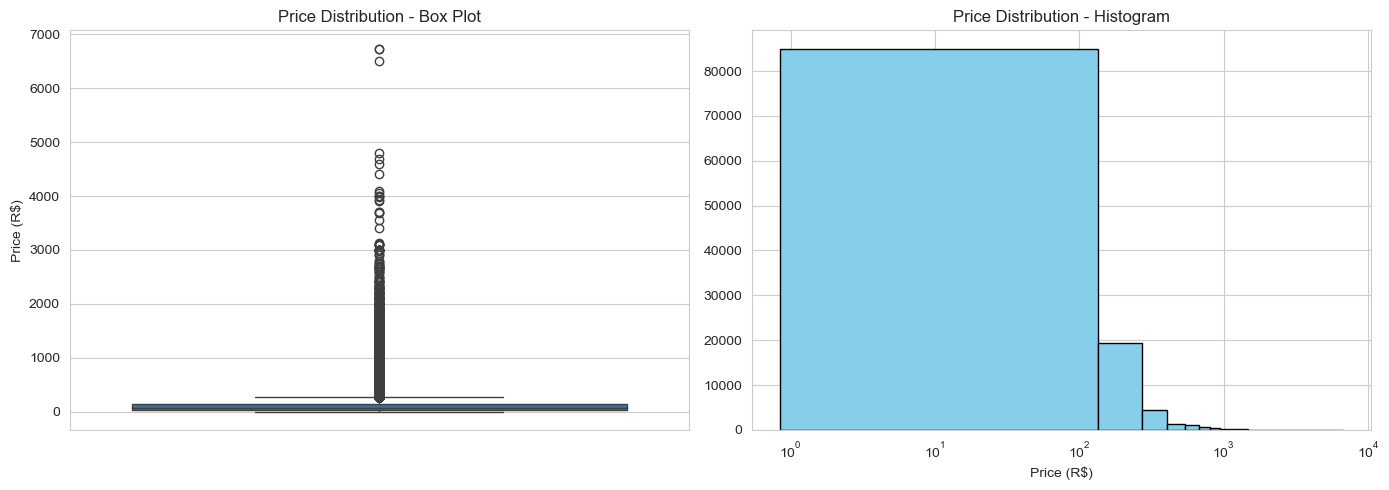

In [97]:
# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title('Price Distribution - Box Plot')
axes[0].set_ylabel('Price (R$)')

# Histogram
df[df['price'] > 0]['price'].hist(bins=50, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Price Distribution - Histogram')
axes[1].set_xlabel('Price (R$)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [98]:
# Check extreme prices
print("Orders with extreme prices (top 10 highest):")
top_prices = df.nlargest(10, 'price')[['order_id', 'product_id', 'price', 'freight_value', 'category']]
top_prices

Orders with extreme prices (top 10 highest):


,order_id,product_id,price,freight_value,category
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00,194.31,housewares
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00,193.21,computers
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00,227.66,art
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00,151.34,small_appliances
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00,74.34,small_appliances
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00,91.78,computers
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87,113.45,musical_instruments
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99,75.27,consoles_games
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00,104.51,sports_leisure
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90,17.01,watches_gifts


In [99]:
# Remove orders with price = 0 (likely data errors)
zero_price = (df['price'] <= 0).sum()
if zero_price > 0:
    print(f"Removing {zero_price} orders with price <= 0")
    df = df[df['price'] > 0]
    print(f"Remaining rows: {len(df):,}")
else:
    print("No zero/negative price orders")

No zero/negative price orders


In [100]:
# Check for extreme freight values
print("Orders where freight > price:")
high_freight = df[df['freight_value'] > df['price']]
print(f"  Count: {len(high_freight):,} ({len(high_freight)/len(df)*100:.1f}%)")
print("  Keeping these (valid for bulky items)")

Orders where freight > price:
  Count: 4,124 (3.7%)
  Keeping these (valid for bulky items)


---
## Step 6: Standardize Column Names

In [101]:
# Display current column names
print("Current column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Current column names:
  1. order_id
  2. order_item_id
  3. product_id
  4. seller_id
  5. shipping_limit_date
  6. price
  7. freight_value
  8. customer_id
  9. order_status
  10. year
  11. month
  12. month_name
  13. quarter
  14. order_purchase_timestamp
  15. delay_days
  16. actual_delivery_days
  17. is_late
  18. delay_bucket
  19. customer_unique_id
  20. customer_state
  21. customer_city
  22. category
  23. seller_state
  24. seller_city
  25. total_payment
  26. payment_type
  27. installments
  28. review_score
  29. sentiment
  30. revenue
  31. is_delivered
  32. has_review


In [102]:
# Rename columns for clarity
rename_map = {
    'category': 'product_category',
    'customer_unique_id': 'customer_id_unique',
    'total_payment': 'payment_total'
}

rename_map = {k: v for k, v in rename_map.items() if k in df.columns}

if rename_map:
    print(f"Renaming {len(rename_map)} columns:")
    for old, new in rename_map.items():
        print(f"  {old} -> {new}")
    df = df.rename(columns=rename_map)
else:
    print("No columns renamed")

Renaming 3 columns:
  category -> product_category
  customer_unique_id -> customer_id_unique
  total_payment -> payment_total


---
## Step 7: Validate Data Quality

In [103]:
# Handle missing payment values (3 rows with null payment_type)
if 'payment_type' in df.columns:
    missing_payment = df['payment_type'].isnull().sum()
    if missing_payment > 0:
        print(f"Filling {missing_payment} missing payment_type values with 'unknown'")
        df['payment_type'] = df['payment_type'].fillna('unknown')
        # Also fill related columns
        if 'payment_total' in df.columns:
            df['payment_total'] = df['payment_total'].fillna(0)
        if 'installments' in df.columns:
            df['installments'] = df['installments'].fillna(0)

---
## Step 8: Create Clean Dataset Summary

In [104]:
print("=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)

summary = {
    'Total Rows': len(df),
    'Total Columns': len(df.columns),
    'Unique Orders': df['order_id'].nunique(),
    'Unique Customers': df['customer_id'].nunique(),
    'Unique Products': df['product_id'].nunique(),
    'Unique Sellers': df['seller_id'].nunique(),
    'Date Range Start': str(df['order_purchase_timestamp'].min()),
    'Date Range End': str(df['order_purchase_timestamp'].max()),
    'Total Revenue': df['revenue'].sum(),
    'Avg Order Value': df.groupby('order_id')['revenue'].sum().mean()
}

for key, value in summary.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value}")

CLEANED DATASET SUMMARY
Total Rows: 112,650.00
Total Columns: 32.00
Unique Orders: 98,666.00
Unique Customers: 98,666.00
Unique Products: 32,951.00
Unique Sellers: 3,095.00
Date Range Start: 2016-09-04 21:15:19
Date Range End: 2018-09-03 09:06:57
Total Revenue: 15,843,553.24
Avg Order Value: 160.58


---
## Step 9: Save Cleaned Dataset

In [105]:
# Save cleaned dataset as CSV
cleaned_file = os.path.join(OUTPUT_PATH, 'cleaned_olist_data.csv')
df.to_csv(cleaned_file, index=False)
print(f"Cleaned dataset saved to: {cleaned_file}")

# Show file size
file_size = os.path.getsize(cleaned_file) / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

Cleaned dataset saved to: C:\Users\KIIT\Desktop\projects\olist-analytics\data\processed\cleaned_olist_data.csv
File size: 38.97 MB


In [106]:
# Verify the saved file
df_verify = pd.read_csv(cleaned_file, nrows=5)
print(f"\nVerification - first 5 rows: {len(df_verify)} rows, {len(df_verify.columns)} columns")
print("File saved successfully!")


Verification - first 5 rows: 5 rows, 32 columns
File saved successfully!


---
## Step 10: Document Cleaning Decisions

In [107]:
# Create a cleaning log
cleaning_log = pd.DataFrame([
    {'Step': 'Drop missing IDs', 'Action': 'Removed rows with missing IDs', 'Reason': 'Critical identifiers cannot be missing'},
    {'Step': 'Fill missing category', 'Action': 'Filled with Unknown', 'Reason': 'Preserve orders for analysis'},
    {'Step': 'Handle missing reviews', 'Action': 'Created has_review flag', 'Reason': 'Not all customers leave reviews'},
    {'Step': 'Convert dates', 'Action': 'Converted to datetime', 'Reason': 'Enable time-based analysis'},
    {'Step': 'Convert categories', 'Action': 'Converted to category dtype', 'Reason': 'Save memory'},
    {'Step': 'Remove zero prices', 'Action': 'Removed orders with price <= 0', 'Reason': 'Data errors or free items'},
    {'Step': 'Keep high freight', 'Action': 'Kept orders where freight > price', 'Reason': 'Valid for bulky items'}
])

# Save cleaning log
log_file = os.path.join(OUTPUT_PATH, 'cleaning_log.csv')
cleaning_log.to_csv(log_file, index=False)
print(f"Cleaning decisions log saved to: {log_file}")

# Display the log
cleaning_log

Cleaning decisions log saved to: C:\Users\KIIT\Desktop\projects\olist-analytics\data\processed\cleaning_log.csv


,Step,Action,Reason
0,Drop missing IDs,Removed rows with missing IDs,Critical identifiers cannot be missing
1,Fill missing category,Filled with Unknown,Preserve orders for analysis
2,Handle missing reviews,Created has_review flag,Not all customers leave reviews
3,Convert dates,Converted to datetime,Enable time-based analysis
4,Convert categories,Converted to category dtype,Save memory
5,Remove zero prices,Removed orders with price <= 0,Data errors or free items
6,Keep high freight,Kept orders where freight > price,Valid for bulky items


---
## End of Data Cleaning Notebook

**Summary:**
- Rows removed: See Step 7
- Missing values: Fixed in critical columns
- Data types: Optimized for analysis
- Files saved: CSV format in processed folder
